# Dimensionality Reduction

In [2]:
import numpy as np
import pandas as pd
from PIL import Image
import os
import matplotlib.pyplot as plt

In [3]:
data_dir = './data/ORL/'

images = []
labels = []

for subject in sorted(os.listdir(data_dir)):
    subject_path = os.path.join(data_dir, subject)
    if not os.path.isdir(subject_path):
        continue
    
    label = int(subject[1:]) # s1 -> 1
    for file in sorted(os.listdir(subject_path)):
        if file.endswith("pgm"):
            img = Image.open(os.path.join(subject_path, file))
            images.append(np.array(img, dtype=np.float64).flatten())
            labels.append(label)
            
X = np.array(images)          # shape (400, 10304)
y = np.array(labels)          # shape (400,)
X.shape, y.shape
 

((400, 10304), (400,))

We've flatten the Images with numpy => $X∈R400×10304$

In [4]:
mean_face = X.mean(axis=0)
X_centered = X - mean_face
X_centered

array([[-37.6175, -36.5775, -40.925 , ..., -29.87  , -29.865 , -29.2275],
       [-51.6175, -51.5775, -52.925 , ..., -39.87  , -35.865 , -42.2275],
       [-25.6175, -25.5775, -23.925 , ..., -44.87  , -41.865 , -41.2275],
       ...,
       [ 26.3825,  23.4225,  30.075 , ...,  16.13  ,  12.135 ,  16.7725],
       [ 25.3825,  28.4225,  26.075 , ...,  11.13  ,  10.135 ,  16.7725],
       [ 24.3825,  26.4225,  27.075 , ...,  15.13  ,  11.135 ,  14.7725]])

- PCA assumes zero-mean data
- Eigenvectors of covariance depend on centering

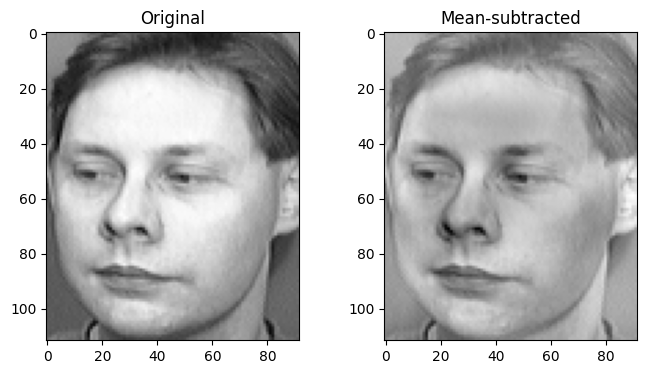

In [5]:
# Let's see the Mean-Subtracted Image next to the original!
idx = np.random.randint(0, len(X))
original = X[idx].reshape(112, 92)
centered = X_centered[idx].reshape(112, 92)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(original, cmap="gray")

plt.subplot(1,2,2)
plt.title("Mean-subtracted")
plt.imshow(centered, cmap="gray")
plt.show()


#### Optional normalization (unit variance)

* Unit variance emphasizes fine details

* May amplify noise

* PCA is sensitive to scaling

In [6]:
std = X_centered.std(axis=0) + 1e-8
X_normalized = X_centered / std
X_normalized

array([[-1.05125993, -1.02502268, -1.15078496, ..., -0.63687931,
        -0.67224364, -0.66490378],
       [-1.4425044 , -1.44537235, -1.48821733, ..., -0.85009635,
        -0.80730013, -0.96064407],
       [-0.71590752, -0.71676625, -0.67275578, ..., -0.95670487,
        -0.94235661, -0.93789481],
       ...,
       [ 0.73728624,  0.65637601,  0.84568986, ...,  0.34391909,
         0.27315174,  0.38156184],
       [ 0.7093402 ,  0.79649257,  0.73321241, ...,  0.23731057,
         0.22813291,  0.38156184],
       [ 0.68139417,  0.74044595,  0.76133177, ...,  0.32259739,
         0.25064232,  0.33606334]])

--- 

### Principal Component Analysis (PCA)


PCA finds orthogonal directions:

$w1​,w2​,…$

_that maximize variance, without using class labels._

It answers:

“Along which directions does the data vary the most?”

""PCA Defined as an orthogonal linear transformation that transforms the data to a new coordinate system
such that the **greatest variance** by some scaler projection of the data comes to lie on the first coordinate (The First Principle Component)""

---

### Eiguen decomposition (efficient PCA)

In [7]:
N = X_centered.shape[0]

# Small covariance
C_small = (X_centered @ X_centered.T) / N
eigvals, eigvecs_small = np.linalg.eigh(C_small)

# Sort descending
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs_small = eigvecs_small[:, idx]

# Map to eigenfaces
eigfaces = X_centered.T @ eigvecs_small
eigfaces = eigfaces / np.linalg.norm(eigfaces, axis=0)


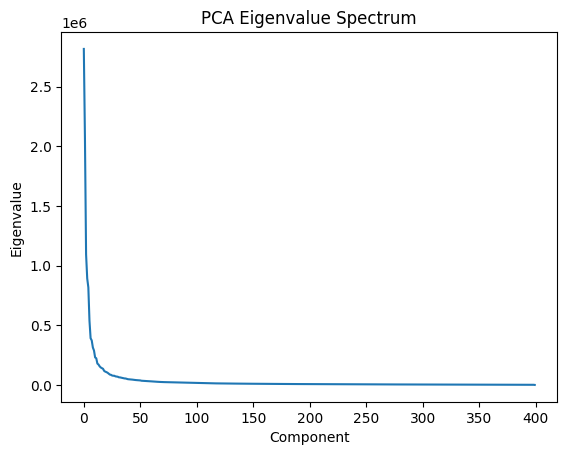

In [8]:
plt.plot(eigvals)
plt.title("PCA Eigenvalue Spectrum")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.show()


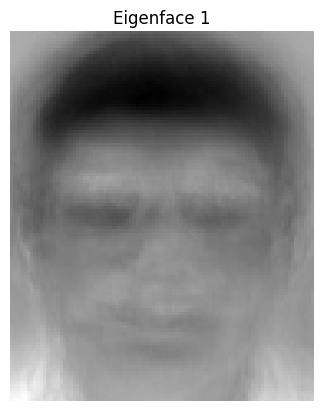

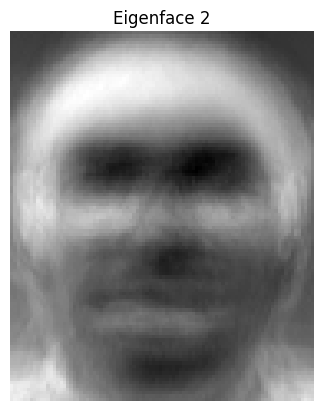

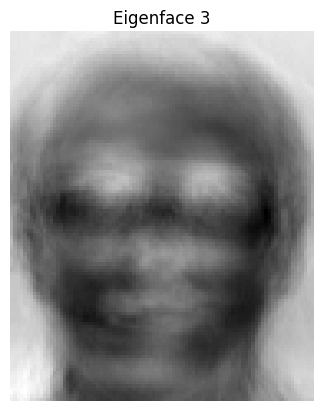

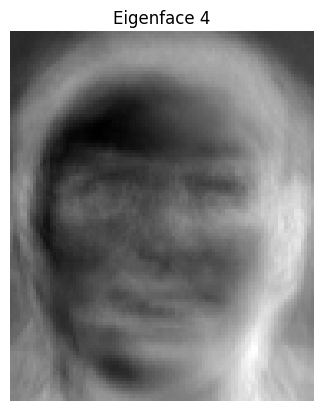

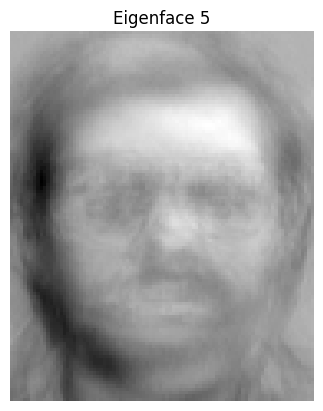

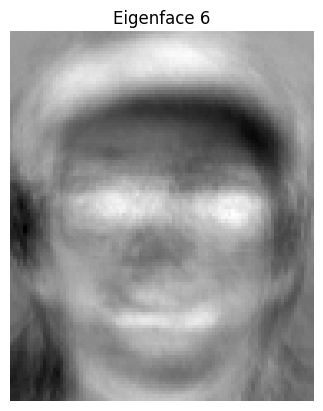

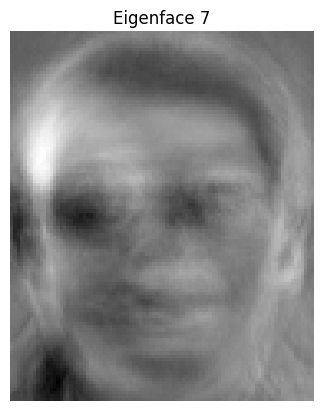

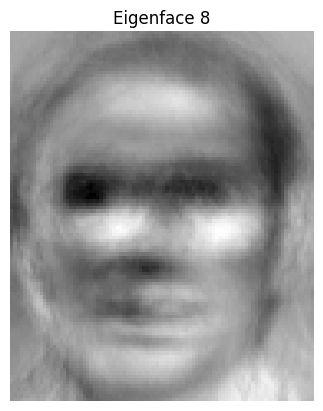

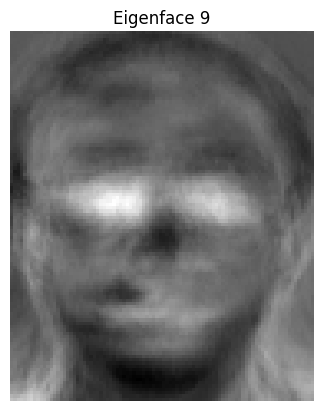

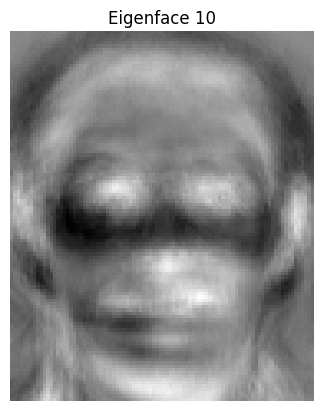

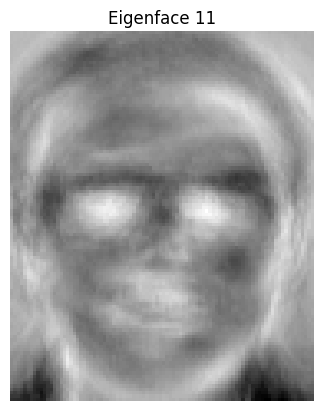

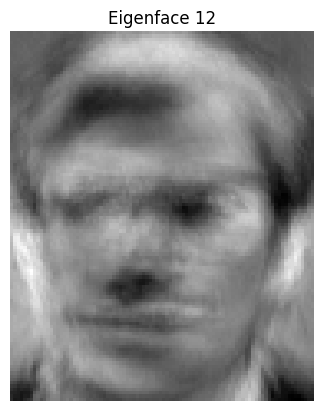

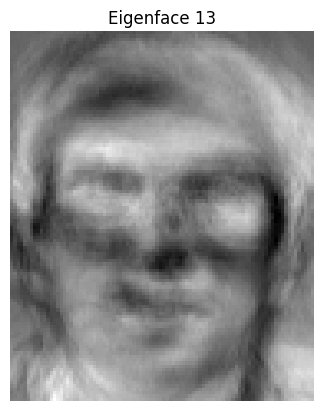

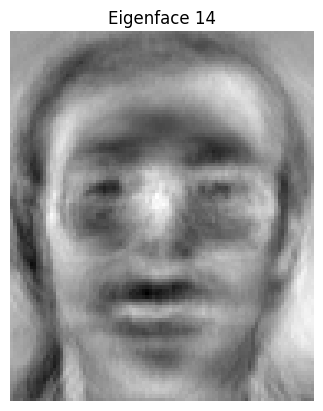

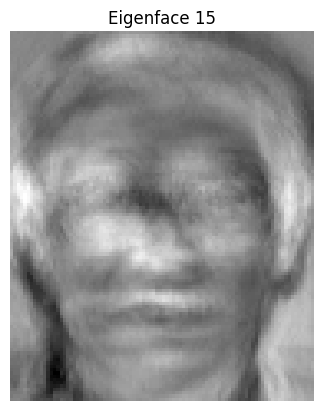

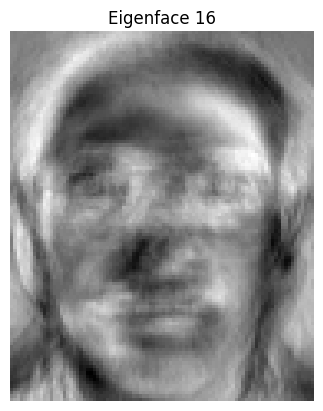

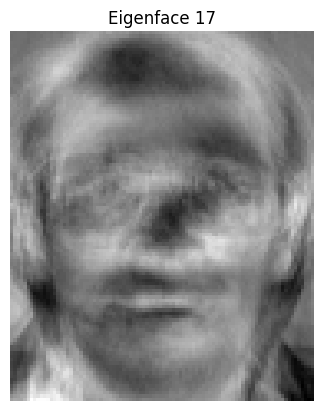

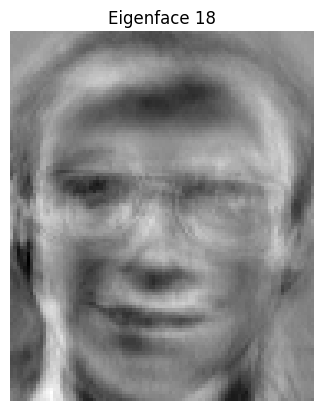

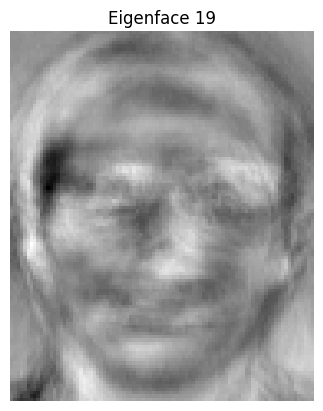

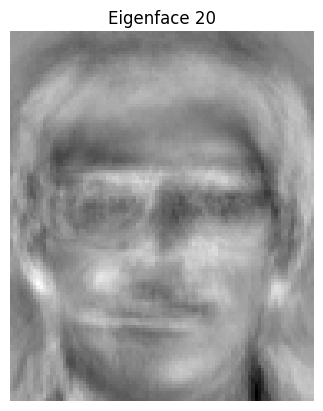

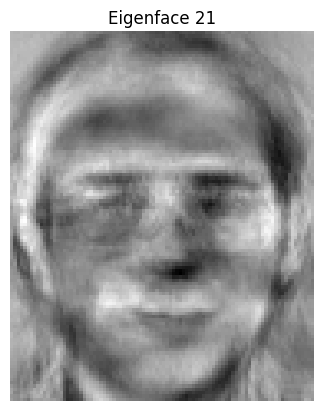

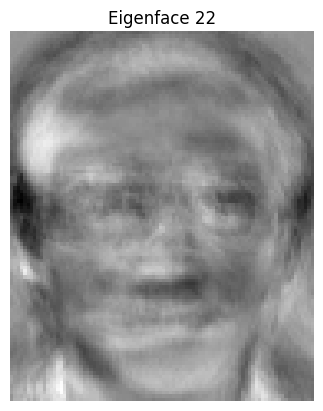

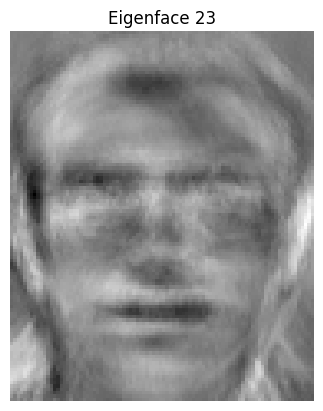

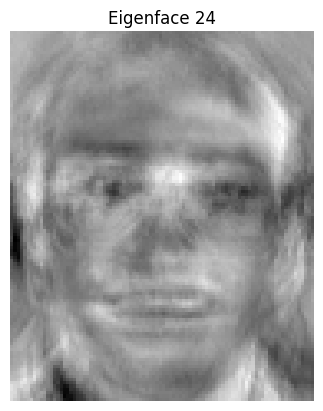

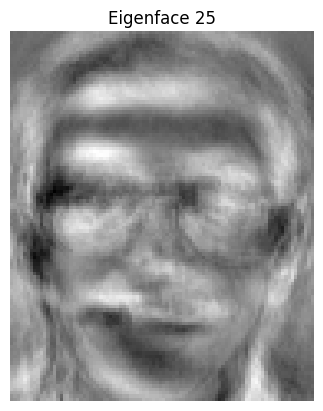

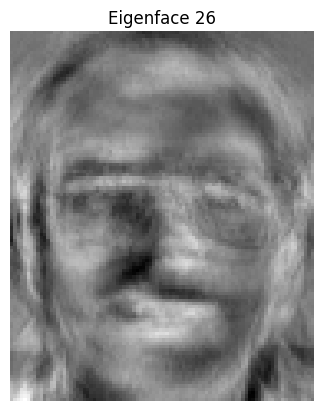

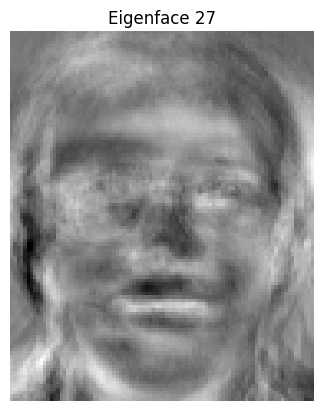

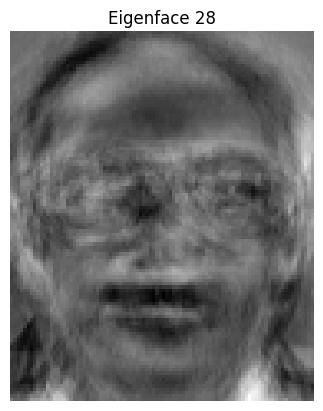

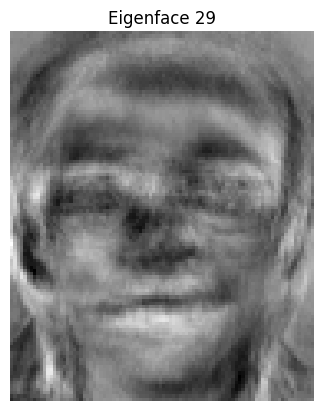

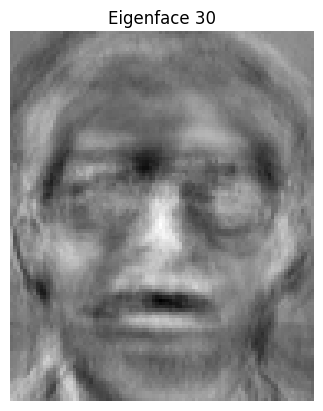

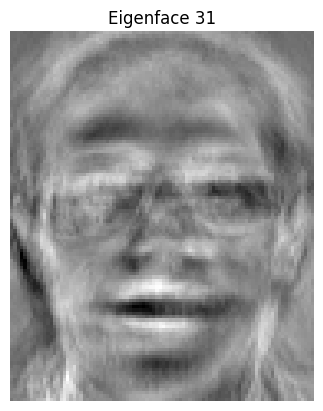

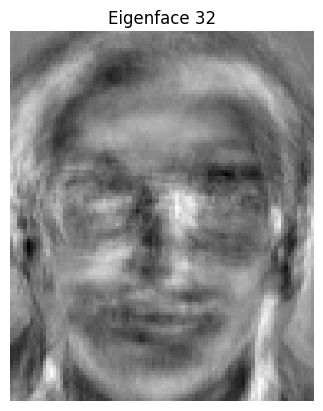

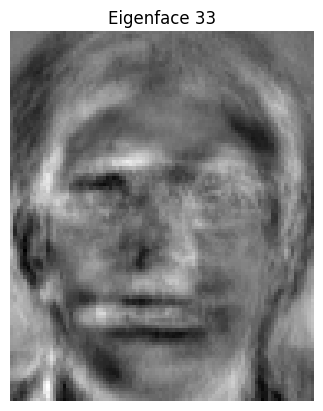

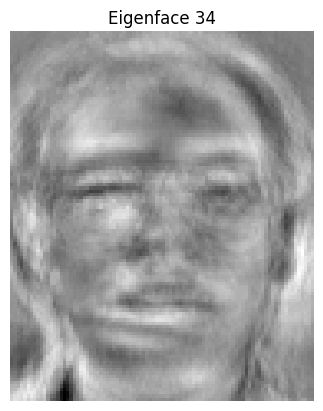

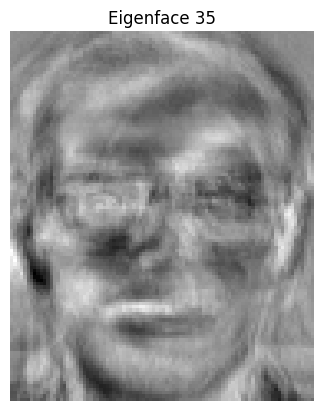

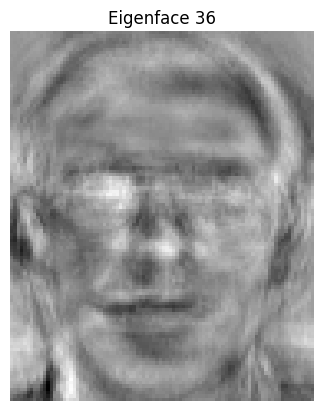

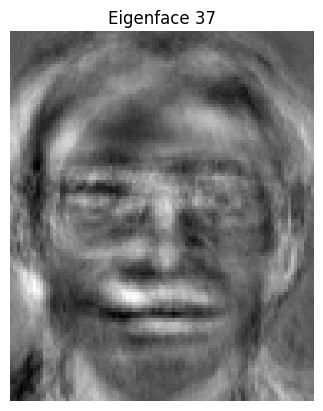

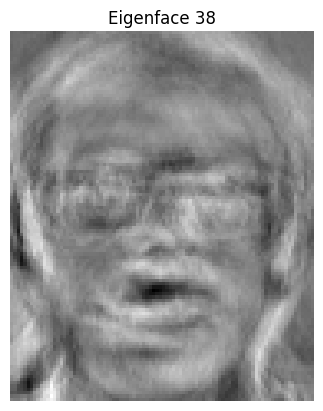

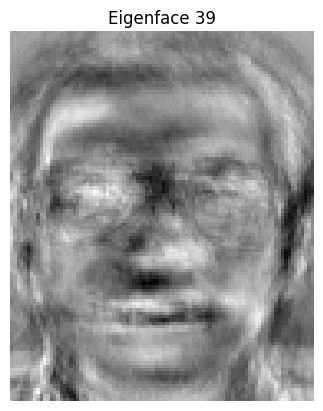

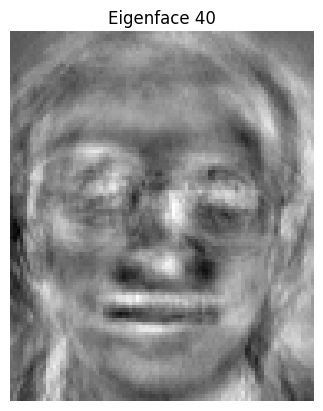

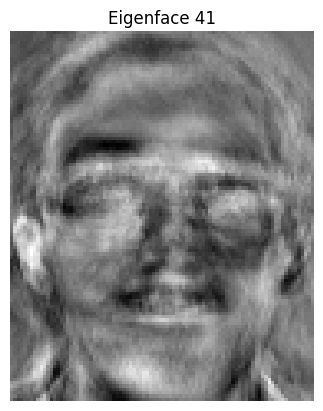

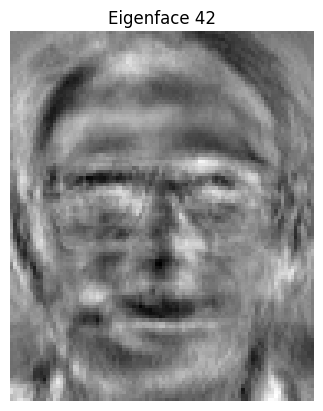

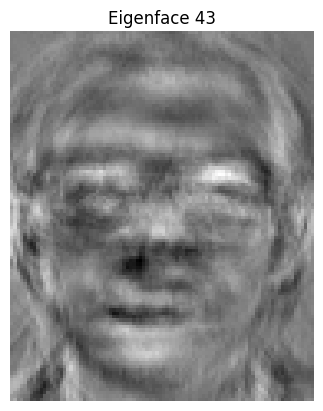

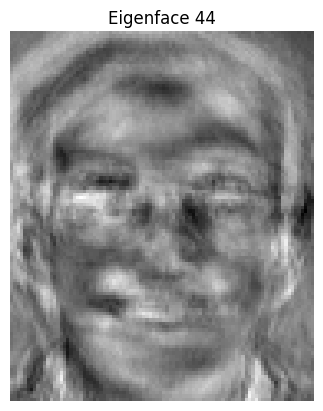

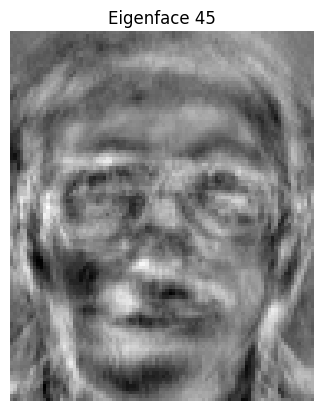

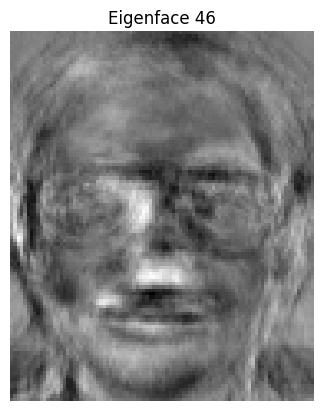

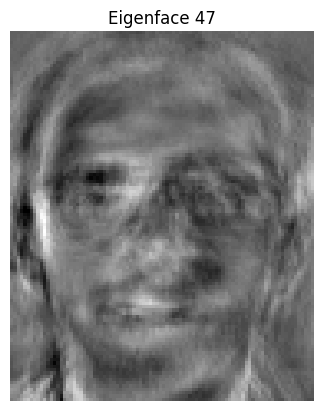

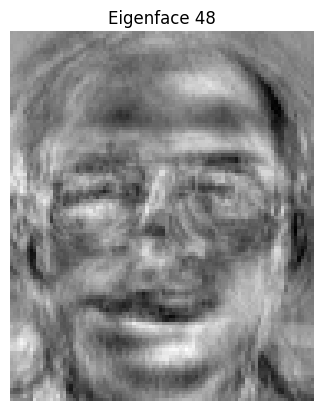

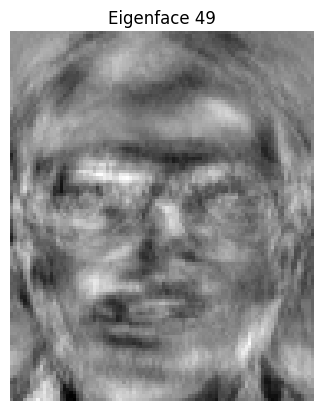

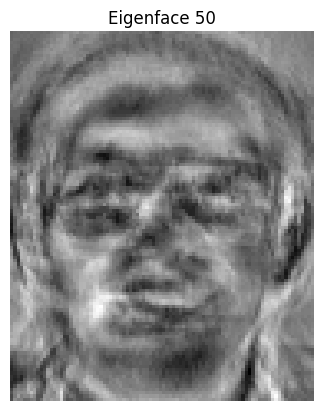

In [9]:
# Top 50 Eigen Faces
for i in range(50):
    plt.figure()
    plt.imshow(eigfaces[:, i].reshape(112, 92), cmap="gray")
    plt.title(f"Eigenface {i+1}")
    plt.axis("off")
    plt.show()


In [10]:
# projection
k = 50
W = eigfaces[:, :k]

X_pca = X_centered @ W

# Reconstruction 
X_recon = X_pca @ W.T + mean_face



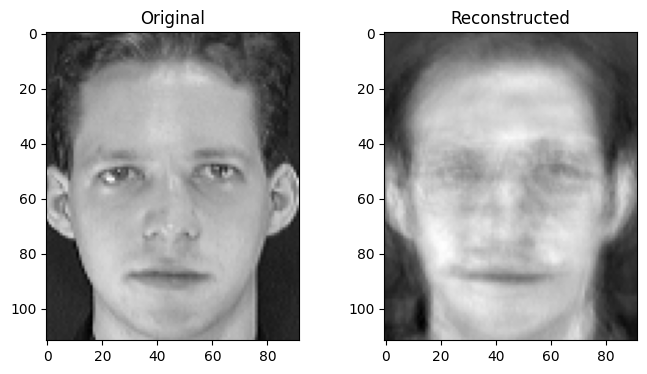

In [11]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(X[0].reshape(112,92), cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(X_recon[0].reshape(112,92), cmap="gray")
plt.title("Reconstructed")
plt.show()


In [12]:
cum_var = np.cumsum(eigvals) / np.sum(eigvals)
num_90 = np.argmax(cum_var >= 0.9) + 1
print(num_90)


111


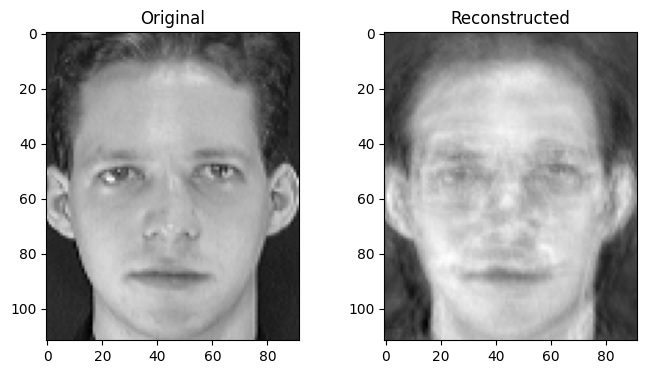

In [13]:
# projection
k = 111
W = eigfaces[:, :k]

X_pca = X_centered @ W

# Reconstruction 
X_recon = X_pca @ W.T + mean_face


plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(X[0].reshape(112,92), cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(X_recon[0].reshape(112,92), cmap="gray")
plt.title("Reconstructed")
plt.show()


#### Why PCA alone is not optimal

- PCA ignores class labels

- Directions of maximum variance ≠ maximum separability

In [14]:
def leave_one_out(X, y):
    train_idx = []
    test_idx = []

    for c in np.unique(y):
        idx = np.where(y == c)[0]
        test = np.random.choice(idx)
        train = np.setdiff1d(idx, test)

        train_idx.extend(train)
        test_idx.append(test)

    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]


In [ ]:
# TODO Write this section Before submission

### Fisher Linear Discriminant Analysis (Fisher LDA)

$J(w) =
\frac{w^T S_B w}{w^T S_W w}$

--- 

#### Whitening

Whitening decorrelates features:

$X \leftarrow \Sigma^{-1/2} X$

_Is it essential?_

- No, mathematically redundant

- Fisher criterion already handles covariance

- Can improve numerical conditioning

---

Scatter Matrices

### Definitions

Let:

* $\mu$ : global mean
* $\mu_c$ : class mean

#### Within-class scatter

$S_W = \sum_c \sum_{x \in c} (x - \mu_c)(x - \mu_c)^T$

#### Between-class scatter

$S_B = \sum_c N_c (\mu_c - \mu)(\mu_c - \mu)^T$


---

In [15]:
classes = np.unique(y)
mu = X.mean(axis=0)

SW = np.zeros((X.shape[1], X.shape[1]))
SB = np.zeros_like(SW)

for c in classes:
    Xc = X[y == c]
    mu_c = Xc.mean(axis=0)

    SW += (Xc - mu_c).T @ (Xc - mu_c)
    diff = (mu_c - mu).reshape(-1,1)
    SB += len(Xc) * (diff @ diff.T)
